<a href="https://colab.research.google.com/github/Rupasri-555/ML-LAB/blob/main/ML_ASSESSMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CONFUSION MATRIX
[[38  3]
 [ 8 11]]

CLASSIFICATION PERFORMANCE
Accuracy           : 81.67 %
Precision          : 78.57 %
Recall             : 57.89 %
F1-Score           : 66.67 %
Specificity        : 92.68 %
False Positive Rate: 7.32 %
False Negative Rate: 42.11 %
Balanced Accuracy  : 75.29 %
ROC-AUC            : 0.8588


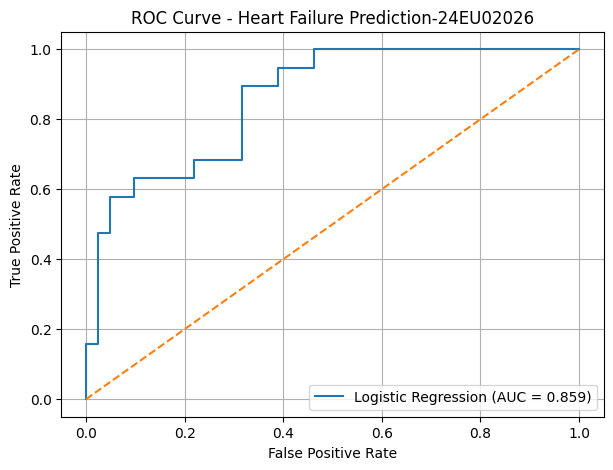

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    roc_curve,
    roc_auc_score
)

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(url)

# Features and target
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

specificity = TN / (TN + FP)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print results
print("CONFUSION MATRIX")
print(cm)

print("\nCLASSIFICATION PERFORMANCE")
print("Accuracy           :", round(accuracy * 100, 2), "%")
print("Precision          :", round(precision * 100, 2), "%")
print("Recall             :", round(recall * 100, 2), "%")
print("F1-Score           :", round(f1 * 100, 2), "%")
print("Specificity        :", round(specificity * 100, 2), "%")
print("False Positive Rate:", round(fpr * 100, 2), "%")
print("False Negative Rate:", round(fnr * 100, 2), "%")
print("Balanced Accuracy  :", round(balanced_accuracy * 100, 2), "%")
print("ROC-AUC            :", round(roc_auc, 4))

# ROC Curve
fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr_curve, tpr_curve, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Failure Prediction-24EU02026")
plt.legend()
plt.grid()
plt.show()

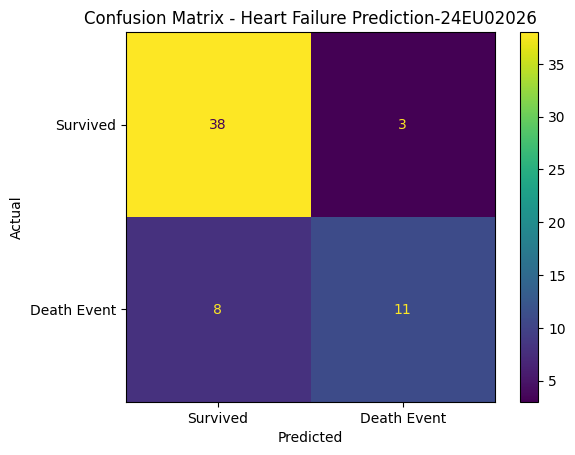

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Survived", "Death Event"]
)

disp.plot()

plt.title("Confusion Matrix - Heart Failure Prediction-24EU02026")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()